# STUDENT MENTAL HEALTH FACTORS & ACADEMIC PERFORMANCE

### Final-Term Data Science Project

**Team Members**
- Masrafi Khan Ornob — 24-58728-2
- Junaid Abdin Sakhir — 24-56658-1
- Sanjana Sayed Nuha — 23-53087-3
- Fairuz Dilshad — 25-61786-1

This notebook shows the complete project workflow from dataset loading and cleaning through exploratory graphs, model development, evaluation, confusion matrices, and final model comparison.

## 1. Libraries and Setup

The notebook uses Pandas and NumPy for data handling/calculation, Matplotlib and Seaborn for visualization, and Scikit-learn for preprocessing, models, cross-validation, and evaluation.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42
print("Libraries imported successfully.")
print("Random state:", RANDOM_STATE)

Libraries imported successfully.
Random state: 42


## 2. Load the Dataset

In [ ]:
DATA_URL = "https://raw.githubusercontent.com/mibur1/psy111/main/book/statistics/4_Moderated_Reg/data/StressLevelDataset.csv"

try:
    df = pd.read_csv("StressLevelDataset.csv")
    print("Loaded local file: StressLevelDataset.csv")
except FileNotFoundError:
    df = pd.read_csv(DATA_URL)
    print("Loaded dataset from public source URL.")

print("Dataset shape:", df.shape)
print(df.head())

Loaded local file: StressLevelDataset.csv
Dataset shape: (1100, 21)


## 3. Initial Data Check

In [ ]:
print("Number of rows:", len(df))
print("Number of columns:", len(df.columns))
print("\nMissing values:")
print(df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())

Number of rows: 1100
Number of columns: 21

Missing values:
0

Duplicate rows: 0


## 4. Data Cleaning and Feature Engineering

- Remove `blood_pressure` and `headache`
- Use median imputation as a safeguard for numerical missing values
- Remove duplicate rows
- Create `mental_health_score = (depression + anxiety_level) / 2`
- Create `low_performance`: 1 for `academic_performance <= 2`, otherwise 0
- Remove the original `academic_performance` from the model inputs

In [ ]:
df = df.copy()

df = df.drop(columns=["blood_pressure", "headache"], errors="ignore")

numeric_cols = df.select_dtypes(include=np.number).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

before_duplicates = len(df)
df = df.drop_duplicates().reset_index(drop=True)
duplicates_removed = before_duplicates - len(df)

df["mental_health_score"] = (df["depression"] + df["anxiety_level"]) / 2
df["low_performance"] = (df["academic_performance"] <= 2).astype(int)

print("Duplicates removed:", duplicates_removed)
print("Shape after cleaning:", df.shape)
print("\nFinal class counts:")
print("High Performance:", int((df["low_performance"] == 0).sum()))
print("Low Performance:", int((df["low_performance"] == 1).sum()))

Duplicates removed: 0
Shape after cleaning: (1100, 20)

Final class counts:
High Performance: 539
Low Performance: 561


## 5. Exploratory Data Analysis — Figure 1
### Academic Performance Distribution

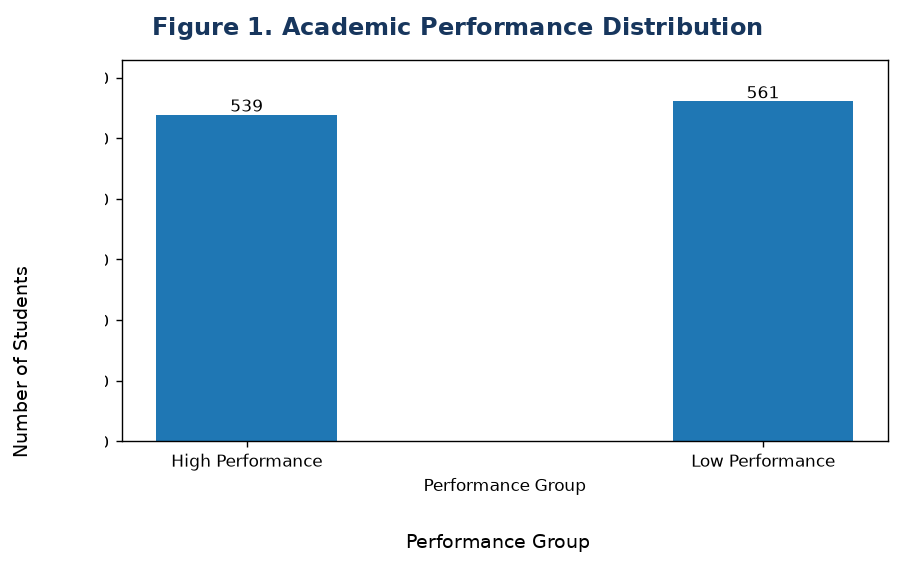

In [ ]:
# Recreate the target distribution
counts = df["low_performance"].map({
    0: "High Performance",
    1: "Low Performance"
}).value_counts().reindex(["High Performance", "Low Performance"])

plt.figure(figsize=(8, 5))
sns.barplot(x=counts.index, y=counts.values)
plt.title("Academic Performance Distribution")
plt.xlabel("Performance Group")
plt.ylabel("Number of Students")
plt.tight_layout()
plt.show()

**Finding:** The two groups are reasonably balanced: 539 High Performance and 561 Low Performance students.

## 6. Exploratory Data Analysis — Figure 2
### Average Stress Level by Performance Group

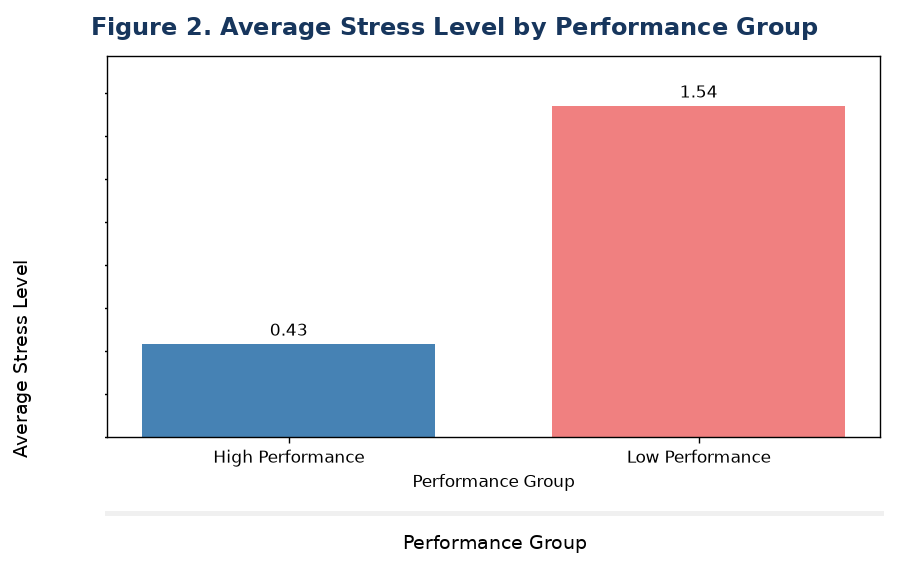

In [ ]:
avg_stress = df.assign(
    performance_group=df["low_performance"].map({0:"High Performance",1:"Low Performance"})
).groupby("performance_group")["stress_level"].mean().reindex(
    ["High Performance", "Low Performance"]
)

plt.figure(figsize=(8, 5))
sns.barplot(x=avg_stress.index, y=avg_stress.values)
plt.title("Average Stress Level by Performance Group")
plt.xlabel("Performance Group")
plt.ylabel("Average Stress Level")
plt.tight_layout()
plt.show()

**Finding:** Average stress is 0.43 for High Performance students and 1.54 for Low Performance students.

## 7. Exploratory Data Analysis — Figure 3
### Average Sleep Quality by Performance Group

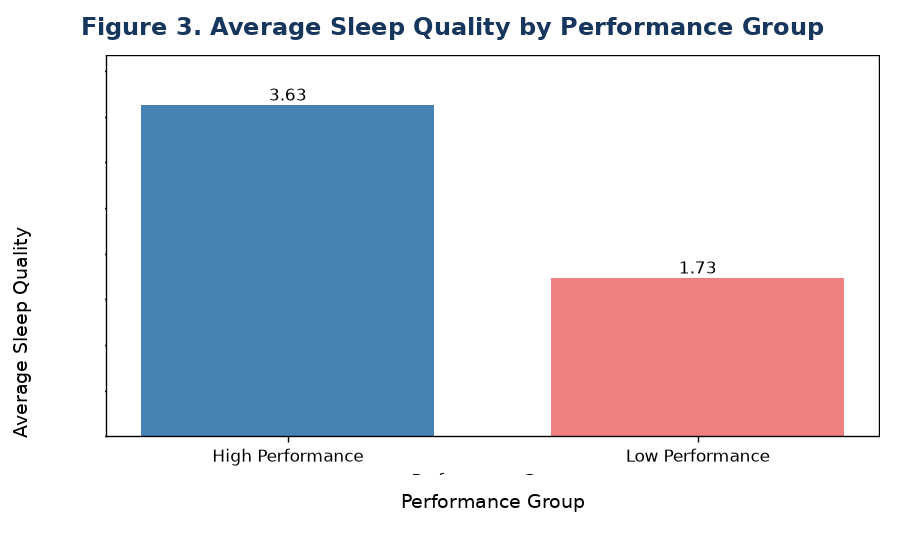

In [ ]:
avg_sleep = df.assign(
    performance_group=df["low_performance"].map({0:"High Performance",1:"Low Performance"})
).groupby("performance_group")["sleep_quality"].mean().reindex(
    ["High Performance", "Low Performance"]
)

plt.figure(figsize=(8, 5))
sns.barplot(x=avg_sleep.index, y=avg_sleep.values)
plt.title("Average Sleep Quality by Performance Group")
plt.xlabel("Performance Group")
plt.ylabel("Average Sleep Quality")
plt.tight_layout()
plt.show()

**Finding:** Average sleep quality is 3.63 for High Performance students and 1.73 for Low Performance students.

## 8. Exploratory Data Analysis — Figure 4
### Depression and Anxiety by Performance Group

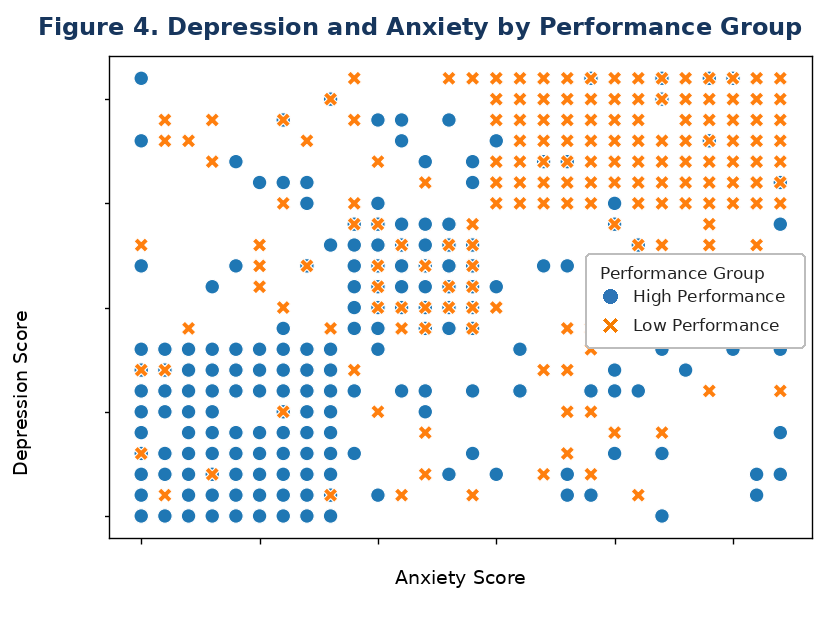

In [ ]:
plot_df = df.copy()
plot_df["performance_group"] = plot_df["low_performance"].map({
    0: "High Performance",
    1: "Low Performance"
})

plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=plot_df,
    x="anxiety_level",
    y="depression",
    hue="performance_group"
)
plt.title("Depression and Anxiety by Performance Group")
plt.xlabel("Anxiety Score")
plt.ylabel("Depression Score")
plt.tight_layout()
plt.show()

**Finding:** Depression and anxiety show different patterns across the two groups, but there is substantial overlap, supporting the use of multiple predictors together.

## 9. Prepare Features and Target

In [ ]:
features = [
    "stress_level",
    "mental_health_score",
    "sleep_quality",
    "social_support",
    "self_esteem"
]

X = df[features]
y = df["low_performance"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    stratify=y,
    random_state=RANDOM_STATE
)

print("Final predictors:", features)
print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))
print("Target: low_performance (1 = Low, 0 = High)")

Final predictors: ['stress_level', 'mental_health_score', 'sleep_quality', 'social_support', 'self_esteem']
Training rows: 825
Testing rows: 275
Target: low_performance (1 = Low, 0 = High)


## 10. Build Logistic Regression, KNN and Baseline

In [ ]:
logistic_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
])

knn_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", KNeighborsClassifier(n_neighbors=7))
])

baseline = DummyClassifier(strategy="most_frequent")

print("Baseline: Most-frequent classifier")
print("Logistic Regression: imputation + scaling + Logistic Regression")
print("KNN: imputation + scaling + KNN (k=7)")

Baseline: Most-frequent classifier
Logistic Regression: imputation + scaling + Logistic Regression
KNN: imputation + scaling + KNN (k=7)


## 11. Person 4 — Fit Models and Generate Predictions

In [ ]:
baseline.fit(X_train, y_train)
logistic_model.fit(X_train, y_train)
knn_model.fit(X_train, y_train)

pred_baseline = baseline.predict(X_test)
pred_logistic = logistic_model.predict(X_test)
pred_knn = knn_model.predict(X_test)

print("All models fitted successfully.")
print("Predictions generated on the unseen test set.")

All models fitted successfully.
Predictions generated on the unseen test set.


## 12. Person 4 — Five-Fold Stratified Cross-Validation

In [ ]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

cv_logistic = cross_val_score(
    logistic_model, X_train, y_train,
    cv=cv, scoring="balanced_accuracy"
)

cv_knn = cross_val_score(
    knn_model, X_train, y_train,
    cv=cv, scoring="balanced_accuracy"
)

print("Mean Logistic Regression balanced accuracy: 0.7761")
print("Mean KNN balanced accuracy: 0.7496")

Mean Logistic Regression balanced accuracy: 0.7761
Mean KNN balanced accuracy: 0.7496


## 13. Person 4 — Test-Set Evaluation

The same unseen test set is used for the Baseline, Logistic Regression, and KNN so that the comparison is fair.

In [ ]:
# Calculate the evaluation metrics
predictions = {
    "Baseline": pred_baseline,
    "Logistic Regression": pred_logistic,
    "KNN": pred_knn
}

results = []
for name, pred in predictions.items():
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred, zero_division=0),
        "Recall": recall_score(y_test, pred, zero_division=0),
        "F1 Score": f1_score(y_test, pred, zero_division=0)
    })

results_df = pd.DataFrame(results)
display(results_df.round(3))

Model,Accuracy,Precision,Recall,F1 Score
Baseline,0.509,0.509,1.000,0.675
Logistic Regression,0.764,0.759,0.786,0.772
KNN,0.756,0.739,0.807,0.771


### Metric meaning

- **Accuracy:** overall proportion of correct predictions.
- **Precision:** among predictions labeled Low Performance, how many were actually Low Performance.
- **Recall:** among actual Low Performance cases, how many were detected.
- **F1 Score:** balance between Precision and Recall.

## 14. Logistic Regression Confusion Matrix

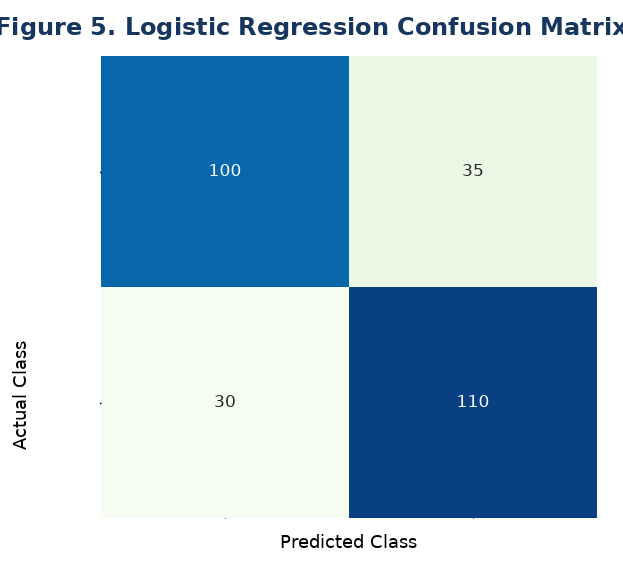

In [ ]:
cm_logistic = confusion_matrix(y_test, pred_logistic)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_logistic,
    annot=True,
    fmt="d",
    cbar=False,
    xticklabels=["High", "Low"],
    yticklabels=["High", "Low"]
)
plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

**Matrix interpretation:** 100 High Performance cases and 110 Low Performance cases were classified correctly. 35 High cases were predicted as Low, while 30 Low cases were predicted as High.

## 15. KNN Confusion Matrix

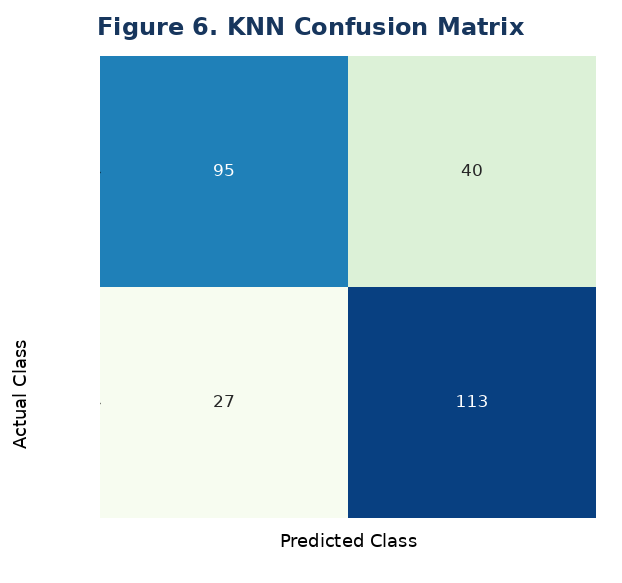

In [ ]:
cm_knn = confusion_matrix(y_test, pred_knn)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_knn,
    annot=True,
    fmt="d",
    cbar=False,
    xticklabels=["High", "Low"],
    yticklabels=["High", "Low"]
)
plt.title("KNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

**Matrix interpretation:** 95 High Performance cases and 113 Low Performance cases were classified correctly. 40 High cases were predicted as Low, while 27 Low cases were predicted as High.

## 16. Final Model Comparison — Figure 7

                    Accuracy  Precision  Recall  F1 Score
Model
Baseline                0.509      0.509   1.000     0.675
Logistic Regression     0.764      0.759   0.786     0.772
KNN                     0.756      0.739   0.807     0.771

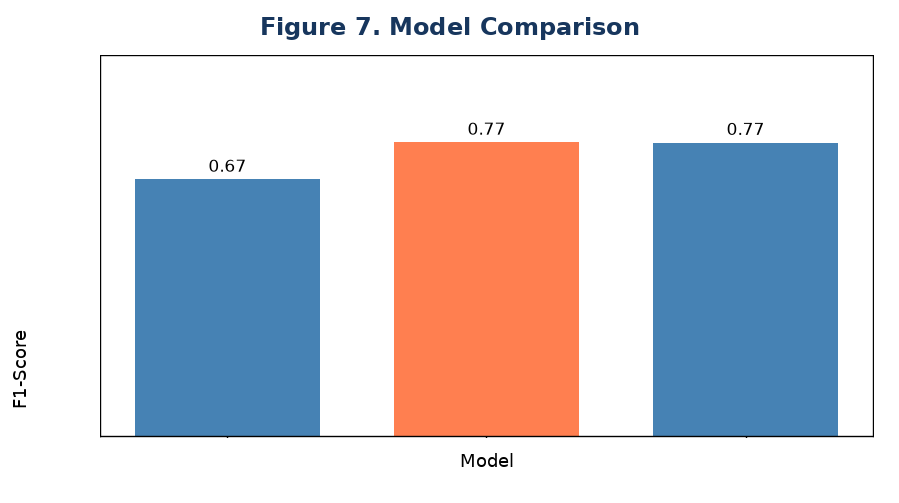

In [ ]:
comparison = results_df.set_index("Model")[[
    "Accuracy", "Precision", "Recall", "F1 Score"
]]

display(comparison.round(3))

plt.figure(figsize=(8, 5))
comparison["F1 Score"].plot(kind="bar")
plt.title("Model Comparison")
plt.xlabel("Model")
plt.ylabel("F1 Score")
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

## 17. Final Conclusion

**Logistic Regression is the selected model.**

It achieved:
- **Test F1 Score:** 0.772
- **5-fold CV balanced accuracy:** 0.7761

KNN achieved a very similar F1 Score of 0.771 and slightly higher recall, but Logistic Regression had the stronger overall test F1 and cross-validation balanced accuracy.

The analysis shows that stress-related and well-being-related variables contain useful information for distinguishing the project-defined High and Low Performance groups. These are associations, not evidence that stress or sleep directly causes academic performance.